Saving house.jfif to house (1).jfif
Original Image:


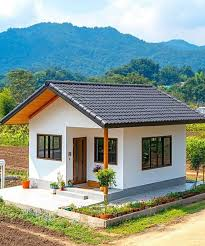

High-Boost Sharpened Image:


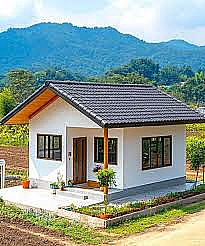

Image saved as sharpened_image.jpg


In [1]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload the image
uploaded = files.upload()

# Get the uploaded image filename
filename = list(uploaded.keys())[0]

# Read the image
image = cv2.imread(filename)

# High-Boost Filtering function
def high_boost_filter(image, boost_factor):
    kernel_size = 3

    # Create averaging kernel
    kernel = np.ones((kernel_size, kernel_size), dtype=np.float32) / (kernel_size ** 2)

    # Blur the image
    blur_image = cv2.filter2D(image, -1, kernel)

    # Apply high-boost filtering
    mask = image.astype(np.float32) + (image.astype(np.float32) - blur_image.astype(np.float32)) * boost_factor

    # Convert values to valid image range
    mask = np.clip(mask, 0, 255).astype(np.uint8)

    return mask

# Apply high-boost filter
sharpened_image = high_boost_filter(image, 1.5)

# Save the result
cv2.imwrite("sharpened_image.jpg", sharpened_image)

# Display original image
print("Original Image:")
cv2_imshow(image)

# Display sharpened image
print("High-Boost Sharpened Image:")
cv2_imshow(sharpened_image)

print("Image saved as sharpened_image.jpg")